# 🎬 NLP Analysis of Movie Overviews

## Анализ описаний фильмов с разделением по рейтингу

**Цель:** Определить, какие слова и фразы характерны для успешных (rating > 6.5) и неуспешных (rating <= 6.5) фильмов на основе их описаний (overview).

### Подход:
1. Загрузка данных и фильтрация по рейтингу
2. Токенизация текста с помощью Keras Tokenizer
3. Анализ частотности слов для успешных/неуспешных фильмов
4. Визуализация различий

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

# Keras for tokenization (updated import for newer versions)
try:
    from keras.preprocessing.text import Tokenizer
    from keras.preprocessing.sequence import pad_sequences
except ImportError:
    from tensorflow.keras.preprocessing.text import Tokenizer
    from tensorflow.keras.preprocessing.sequence import pad_sequences

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Load data
df = pd.read_csv('data/TMDB_all_movies.csv')

# Check relevant columns
print(f"Total movies: {len(df):,}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nOverview column non-null: {df['overview'].notna().sum():,}")
print(f"Vote average column non-null: {df['vote_average'].notna().sum():,}")

Total movies: 1,137,484

Columns: ['id', 'title', 'vote_average', 'vote_count', 'status', 'release_date', 'revenue', 'runtime', 'budget', 'imdb_id', 'original_language', 'original_title', 'overview', 'popularity', 'tagline', 'genres', 'production_companies', 'production_countries', 'spoken_languages', 'cast', 'director', 'director_of_photography', 'writers', 'producers', 'music_composer', 'imdb_rating', 'imdb_votes', 'poster_path']

Overview column non-null: 962,500
Vote average column non-null: 1,137,484


## 📊 Разделение фильмов по рейтингу

**Критерий успешности:**
- ✅ **Успешный фильм:** rating > 6.5
- ❌ **Неуспешный фильм:** rating <= 6.5

РАСПРЕДЕЛЕНИЕ ФИЛЬМОВ ПО РЕЙТИНГУ

✅ Успешные фильмы (rating > 6.5): 122,289
❌ Неуспешные фильмы (rating <= 6.5): 231,053

Всего фильмов с overview: 353,342


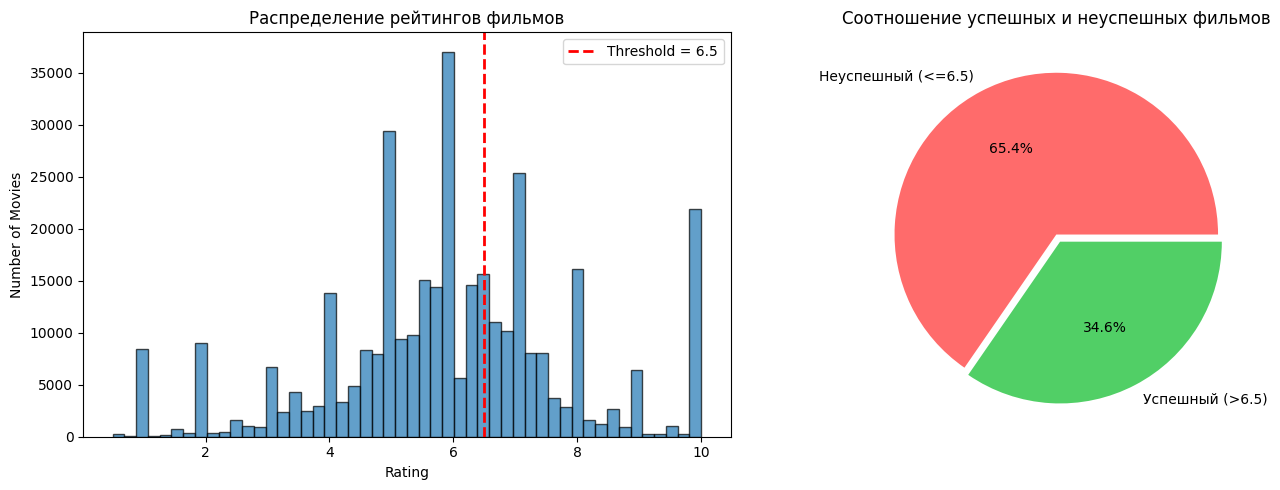

In [4]:
# Filter and prepare data
df_clean = df[['title', 'overview', 'vote_average']].dropna()
df_clean = df_clean[df_clean['vote_average'] > 0]  # Remove movies with no votes

# Define success threshold
RATING_THRESHOLD = 6.5

# Create success label
df_clean['is_successful'] = (df_clean['vote_average'] > RATING_THRESHOLD).astype(int)
df_clean['label'] = df_clean['is_successful'].map({1: '✅ Успешный (>6.5)', 0: '❌ Неуспешный (<=6.5)'})

# Show distribution
print("=" * 50)
print("РАСПРЕДЕЛЕНИЕ ФИЛЬМОВ ПО РЕЙТИНГУ")
print("=" * 50)
print(f"\n✅ Успешные фильмы (rating > 6.5): {df_clean['is_successful'].sum():,}")
print(f"❌ Неуспешные фильмы (rating <= 6.5): {(df_clean['is_successful'] == 0).sum():,}")
print(f"\nВсего фильмов с overview: {len(df_clean):,}")

# Show rating distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df_clean['vote_average'], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(x=RATING_THRESHOLD, color='red', linestyle='--', linewidth=2, label=f'Threshold = {RATING_THRESHOLD}')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Number of Movies')
axes[0].set_title('Распределение рейтингов фильмов')
axes[0].legend()

# Pie chart
success_counts = df_clean['is_successful'].value_counts()
axes[1].pie(success_counts.values, labels=['Неуспешный (<=6.5)', 'Успешный (>6.5)'], 
            autopct='%1.1f%%', colors=['#ff6b6b', '#51cf66'], explode=[0, 0.05])
axes[1].set_title('Соотношение успешных и неуспешных фильмов')

plt.tight_layout()
plt.show()

## 🔤 Предобработка текста и токенизация

Очистка текста от специальных символов и токенизация с помощью Keras Tokenizer

In [5]:
# Text preprocessing function
def clean_text(text):
    """Clean and preprocess text"""
    if pd.isna(text):
        return ""
    
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)  # Remove non-alphabetic characters
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra whitespace
    
    return text

# Apply cleaning
df_clean['overview_clean'] = df_clean['overview'].apply(clean_text)

# Remove empty overviews
df_clean = df_clean[df_clean['overview_clean'].str.len() > 10]

print(f"Movies after cleaning: {len(df_clean):,}")
print(f"\nExample cleaned overview:")
print(f"Original: {df_clean['overview'].iloc[0][:200]}...")
print(f"\nCleaned: {df_clean['overview_clean'].iloc[0][:200]}...")

Movies after cleaning: 353,149

Example cleaned overview:
Original: A Finnish man goes to the city to find a job after the mine where he worked is closed and his father commits suicide....

Cleaned: a finnish man goes to the city to find a job after the mine where he worked is closed and his father commits suicide...


In [6]:
# Separate successful and unsuccessful movie overviews
successful_overviews = df_clean[df_clean['is_successful'] == 1]['overview_clean'].tolist()
unsuccessful_overviews = df_clean[df_clean['is_successful'] == 0]['overview_clean'].tolist()

print(f"✅ Успешные фильмы (rating > 6.5): {len(successful_overviews):,} описаний")
print(f"❌ Неуспешные фильмы (rating <= 6.5): {len(unsuccessful_overviews):,} описаний")

# All sentences for tokenization
all_sentences = df_clean['overview_clean'].tolist()
print(f"\nВсего предложений для токенизации: {len(all_sentences):,}")

✅ Успешные фильмы (rating > 6.5): 122,238 описаний
❌ Неуспешные фильмы (rating <= 6.5): 230,911 описаний

Всего предложений для токенизации: 353,149


In [7]:
# Keras Tokenizer for ALL overviews
tokenizer = Tokenizer()
tokenizer.fit_on_texts(all_sentences)

# Convert to sequences
X = tokenizer.texts_to_sequences(all_sentences)

# Vocabulary size (+1 because 0 is reserved)
vocab_size = len(tokenizer.word_index) + 1

print("=" * 60)
print("РЕЗУЛЬТАТЫ ТОКЕНИЗАЦИИ (Keras Tokenizer)")
print("=" * 60)
print(f"\n📚 Размер словаря: {vocab_size:,} слов")
print(f"📝 Количество документов: {len(X):,}")

# Example
print(f"\n--- Пример токенизации ---")
print(f"Оригинальный текст: {all_sentences[2][:100]}...")
print(f"Токены (индексы): {X[2][:20]}...")
print(f"Длина последовательности: {len(X[2])}")

РЕЗУЛЬТАТЫ ТОКЕНИЗАЦИИ (Keras Tokenizer)

📚 Размер словаря: 294,708 слов
📝 Количество документов: 353,149

--- Пример токенизации ---
Оригинальный текст: its ted the bellhops first night on the joband the hotels very unusual guests are about to place him...
Токены (индексы): [57, 3745, 1, 45918, 63, 119, 13, 1, 77740, 1, 7315, 158, 1223, 1392, 27, 37, 5, 148, 32, 6]...
Длина последовательности: 38


In [8]:
# Show word_index (first 30 most frequent words)
print("🔤 Топ-30 самых частых слов в словаре:")
print("-" * 40)

word_index_sorted = sorted(tokenizer.word_index.items(), key=lambda x: x[1])[:30]
for word, idx in word_index_sorted:
    print(f"{idx:3d}: '{word}'")

🔤 Топ-30 самых частых слов в словаре:
----------------------------------------
  1: 'the'
  2: 'a'
  3: 'and'
  4: 'of'
  5: 'to'
  6: 'in'
  7: 'is'
  8: 'his'
  9: 'with'
 10: 'her'
 11: 'for'
 12: 'he'
 13: 'on'
 14: 'an'
 15: 'that'
 16: 'by'
 17: 'as'
 18: 'who'
 19: 'their'
 20: 'from'
 21: 'but'
 22: 'she'
 23: 'they'
 24: 'at'
 25: 'when'
 26: 'has'
 27: 'are'
 28: 'this'
 29: 'it'
 30: 'life'


## 📈 Анализ слов для успешных vs неуспешных фильмов

Создаём отдельные токенизаторы для каждой категории и сравниваем частотность слов

In [9]:
# Create separate tokenizers for successful and unsuccessful movies
tokenizer_success = Tokenizer()
tokenizer_success.fit_on_texts(successful_overviews)

tokenizer_fail = Tokenizer()
tokenizer_fail.fit_on_texts(unsuccessful_overviews)

# Get word counts
success_word_counts = tokenizer_success.word_counts
fail_word_counts = tokenizer_fail.word_counts

print(f"✅ Уникальных слов в успешных фильмах: {len(success_word_counts):,}")
print(f"❌ Уникальных слов в неуспешных фильмах: {len(fail_word_counts):,}")

✅ Уникальных слов в успешных фильмах: 163,519
❌ Уникальных слов в неуспешных фильмах: 221,386


In [10]:
# Define stop words to filter out
STOP_WORDS = {
    'the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for', 'of', 'with',
    'by', 'from', 'as', 'is', 'was', 'are', 'were', 'been', 'be', 'have', 'has', 'had',
    'do', 'does', 'did', 'will', 'would', 'could', 'should', 'may', 'might', 'must',
    'shall', 'can', 'need', 'it', 'its', 'this', 'that', 'these', 'those', 'i', 'you',
    'he', 'she', 'we', 'they', 'what', 'which', 'who', 'whom', 'where', 'when', 'why',
    'how', 'all', 'each', 'every', 'both', 'few', 'more', 'most', 'other', 'some',
    'such', 'no', 'nor', 'not', 'only', 'own', 'same', 'so', 'than', 'too', 'very',
    'just', 'also', 'now', 'here', 'there', 'then', 'once', 'if', 'because', 'until',
    'while', 'although', 'though', 'after', 'before', 'about', 'into', 'through',
    'during', 'above', 'below', 'between', 'under', 'again', 'further', 'out', 'up',
    'down', 'off', 'over', 'any', 'him', 'her', 'his', 'their', 'them', 'my', 'your',
    'our', 'me', 'us', 'being', 'having', 'doing', 'one', 'two', 'first', 'new',
    'man', 'woman', 'find', 'finds', 'take', 'takes', 'make', 'makes', 'go', 'goes',
    'come', 'comes', 'see', 'sees', 'know', 'knows', 'get', 'gets', 'got', 'become',
    'becomes', 'becomes', 'young', 'old', 'life', 'lives', 'story', 'film', 'movie',
    'world', 'time', 'day', 'way', 'year', 'years', 'back', 'even', 'well', 'still',
    'much', 'many', 'own', 'away', 'part', 'set', 'work', 'must', 'however', 'another'
}

def get_top_words(word_counts, n=30, exclude_stopwords=True):
    """Get top N words excluding stop words"""
    if exclude_stopwords:
        filtered = {k: v for k, v in word_counts.items() if k not in STOP_WORDS and len(k) > 2}
    else:
        filtered = word_counts
    
    sorted_words = sorted(filtered.items(), key=lambda x: x[1], reverse=True)
    return sorted_words[:n]

# Get top words for each category
top_success_words = get_top_words(success_word_counts, 30)
top_fail_words = get_top_words(fail_word_counts, 30)

print("✅ ТОП-20 слов в УСПЕШНЫХ фильмах (rating > 6.5):")
print("-" * 50)
for word, count in top_success_words[:20]:
    print(f"  {word:<20} : {count:,}")

print("\n❌ ТОП-20 слов в НЕУСПЕШНЫХ фильмах (rating <= 6.5):")
print("-" * 50)
for word, count in top_fail_words[:20]:
    print(f"  {word:<20} : {count:,}")

✅ ТОП-20 слов в УСПЕШНЫХ фильмах (rating > 6.5):
--------------------------------------------------
  love                 : 11,165
  family               : 9,705
  documentary          : 8,548
  live                 : 7,802
  people               : 6,967
  friends              : 6,290
  home                 : 6,238
  father               : 5,877
  three                : 5,667
  girl                 : 5,620
  music                : 5,275
  mother               : 5,204
  war                  : 5,203
  school               : 4,805
  journey              : 4,805
  city                 : 4,785
  together             : 4,758
  against              : 4,668
  death                : 4,530
  like                 : 4,503

❌ ТОП-20 слов в НЕУСПЕШНЫХ фильмах (rating <= 6.5):
--------------------------------------------------
  love                 : 26,653
  family               : 20,048
  friends              : 13,638
  father               : 13,614
  girl                 : 13,526
  home         

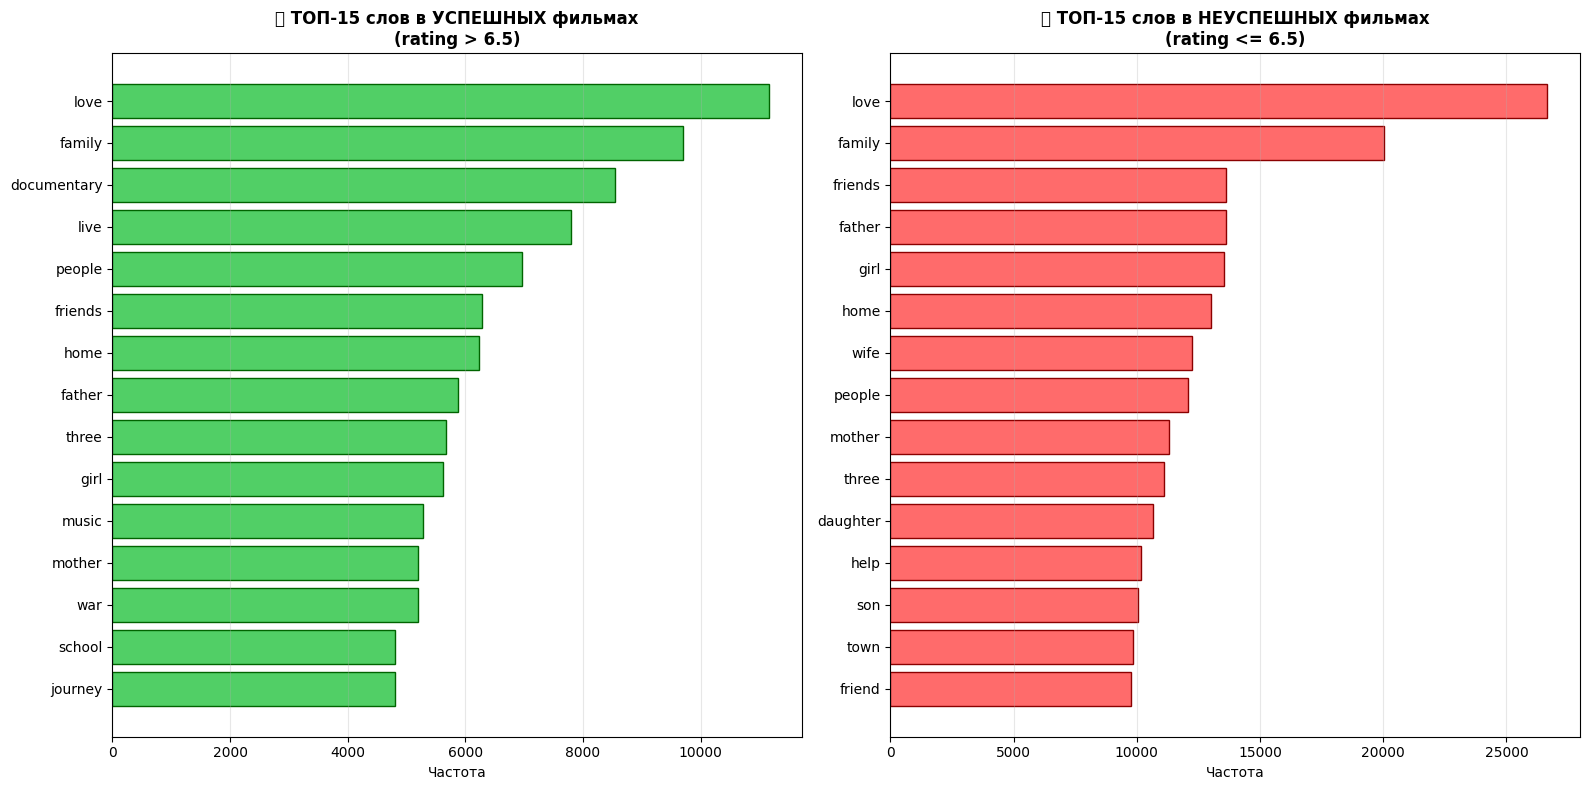

In [11]:
# Visualize top words comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Successful movies
success_words = [w[0] for w in top_success_words[:15]]
success_counts = [w[1] for w in top_success_words[:15]]

axes[0].barh(success_words[::-1], success_counts[::-1], color='#51cf66', edgecolor='darkgreen')
axes[0].set_xlabel('Частота')
axes[0].set_title('✅ ТОП-15 слов в УСПЕШНЫХ фильмах\n(rating > 6.5)', fontsize=12, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Unsuccessful movies
fail_words = [w[0] for w in top_fail_words[:15]]
fail_counts = [w[1] for w in top_fail_words[:15]]

axes[1].barh(fail_words[::-1], fail_counts[::-1], color='#ff6b6b', edgecolor='darkred')
axes[1].set_xlabel('Частота')
axes[1].set_title('❌ ТОП-15 слов в НЕУСПЕШНЫХ фильмах\n(rating <= 6.5)', fontsize=12, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 🔍 Уникальные слова для каждой категории

Найдём слова, которые ЧАЩЕ встречаются в успешных фильмах vs неуспешных (относительная частота)

In [12]:
# Calculate relative frequency (normalized by number of documents)
n_success = len(successful_overviews)
n_fail = len(unsuccessful_overviews)

# Get all words that appear in both
common_words = set(success_word_counts.keys()) & set(fail_word_counts.keys())

# Calculate success ratio for each word
word_ratios = {}
for word in common_words:
    if word in STOP_WORDS or len(word) <= 2:
        continue
    
    # Normalized frequency
    success_freq = success_word_counts.get(word, 0) / n_success
    fail_freq = fail_word_counts.get(word, 0) / n_fail
    
    # Minimum count threshold
    if success_word_counts.get(word, 0) + fail_word_counts.get(word, 0) < 100:
        continue
    
    if fail_freq > 0:
        ratio = success_freq / fail_freq
        word_ratios[word] = {
            'ratio': ratio,
            'success_count': success_word_counts.get(word, 0),
            'fail_count': fail_word_counts.get(word, 0),
            'success_freq': success_freq,
            'fail_freq': fail_freq
        }

# Sort by ratio
words_more_in_success = sorted(word_ratios.items(), key=lambda x: x[1]['ratio'], reverse=True)[:20]
words_more_in_fail = sorted(word_ratios.items(), key=lambda x: x[1]['ratio'])[:20]

print("=" * 70)
print("🌟 СЛОВА, КОТОРЫЕ ЧАЩЕ В УСПЕШНЫХ ФИЛЬМАХ (vs неуспешных)")
print("=" * 70)
print(f"{'Слово':<15} {'Ratio':<8} {'✅ Success':<12} {'❌ Fail':<12}")
print("-" * 50)
for word, data in words_more_in_success:
    print(f"{word:<15} {data['ratio']:.2f}x    {data['success_count']:<12,} {data['fail_count']:<12,}")

print("\n" + "=" * 70)
print("💔 СЛОВА, КОТОРЫЕ ЧАЩЕ В НЕУСПЕШНЫХ ФИЛЬМАХ (vs успешных)")
print("=" * 70)
print(f"{'Слово':<15} {'Ratio':<8} {'✅ Success':<12} {'❌ Fail':<12}")
print("-" * 50)
for word, data in words_more_in_fail:
    print(f"{word:<15} {1/data['ratio']:.2f}x    {data['success_count']:<12,} {data['fail_count']:<12,}")

🌟 СЛОВА, КОТОРЫЕ ЧАЩЕ В УСПЕШНЫХ ФИЛЬМАХ (vs неуспешных)
Слово           Ratio    ✅ Success    ❌ Fail      
--------------------------------------------------
scoobydoo       50.53x    107          4           
nxt             18.09x    182          19          
cena            15.56x    140          17          
wrestlemania    12.55x    186          28          
smackdown       11.85x    207          33          
orton           11.00x    99           17          
godzilla        10.48x    122          22          
wwe             8.66x    999          218         
climbers        8.59x    191          42          
setlist         7.59x    205          51          
ecw             7.41x    149          38          
wembley         7.25x    96           25          
remastered      7.05x    97           26          
undercard       6.52x    107          31          
bluray          6.08x    206          64          
sentai          5.49x    93           32          
vocals          5.

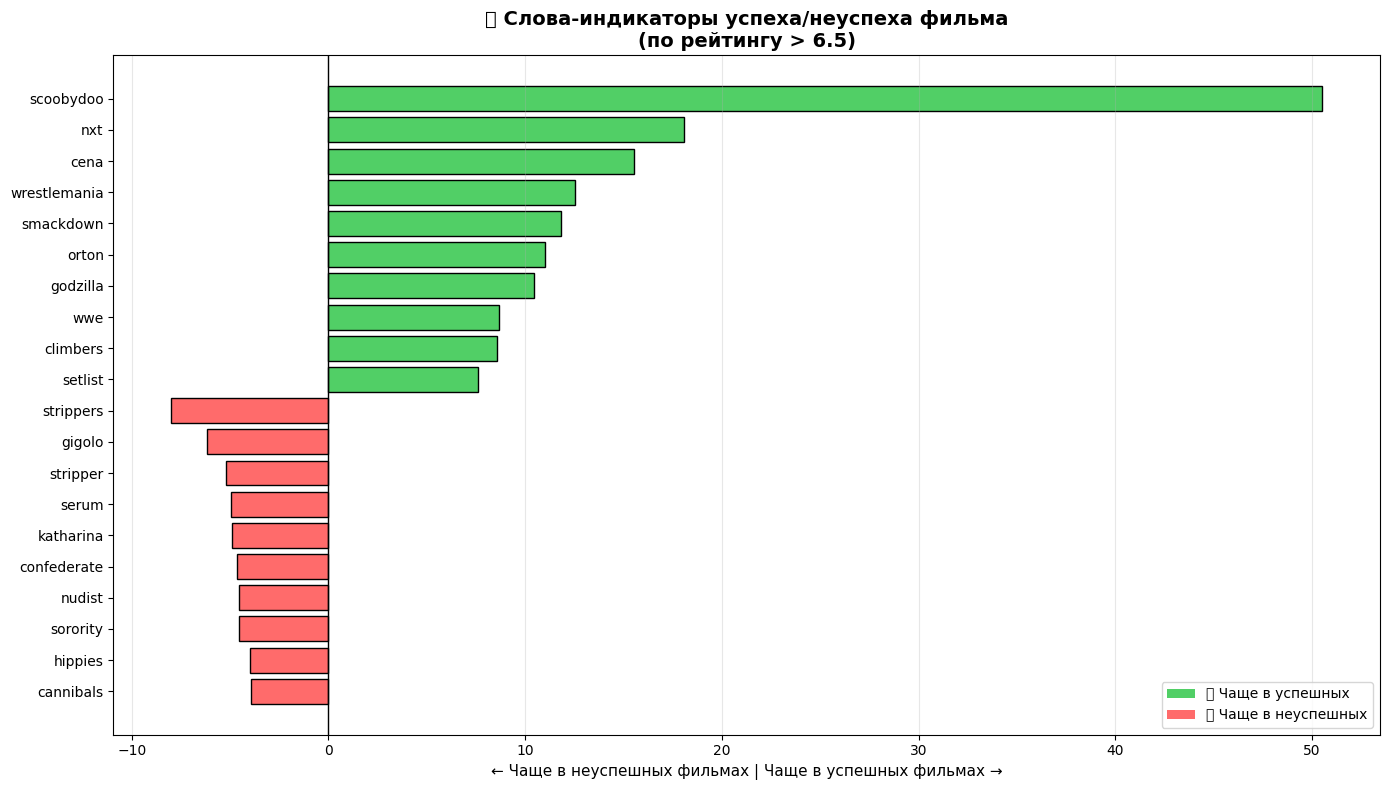

In [13]:
# Visualize word ratio comparison
fig, ax = plt.subplots(figsize=(14, 8))

# Prepare data
success_words_data = [(w, d['ratio']) for w, d in words_more_in_success[:10]]
fail_words_data = [(w, 1/d['ratio']) for w, d in words_more_in_fail[:10]]

# Combine
all_words = [w for w, _ in success_words_data] + [w for w, _ in fail_words_data]
all_ratios = [r for _, r in success_words_data] + [-r for _, r in fail_words_data]
colors = ['#51cf66'] * 10 + ['#ff6b6b'] * 10

# Plot
bars = ax.barh(all_words[::-1], all_ratios[::-1], color=colors[::-1], edgecolor='black')

ax.axvline(x=0, color='black', linewidth=1)
ax.set_xlabel('← Чаще в неуспешных фильмах | Чаще в успешных фильмах →', fontsize=11)
ax.set_title('📊 Слова-индикаторы успеха/неуспеха фильма\n(по рейтингу > 6.5)', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#51cf66', label='✅ Чаще в успешных'),
                   Patch(facecolor='#ff6b6b', label='❌ Чаще в неуспешных')]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

## 📝 Padding последовательностей для ML модели

Приводим все последовательности к одинаковой длине для использования в нейросети

📏 Статистика длин последовательностей:
  Min: 1
  Max: 202
  Mean: 48.9
  Median: 40.0
  95th percentile: 119


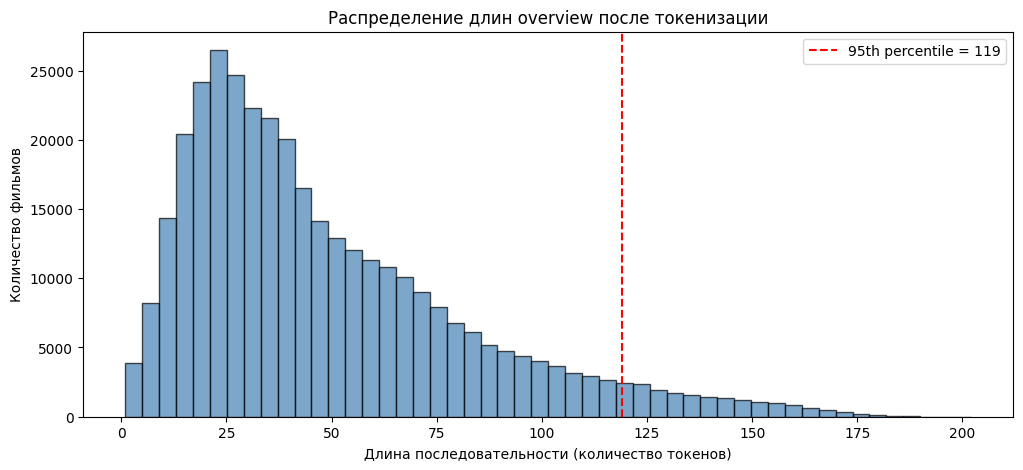

In [14]:
# Analyze sequence lengths
sequence_lengths = [len(seq) for seq in X]

print("📏 Статистика длин последовательностей:")
print(f"  Min: {min(sequence_lengths)}")
print(f"  Max: {max(sequence_lengths)}")
print(f"  Mean: {np.mean(sequence_lengths):.1f}")
print(f"  Median: {np.median(sequence_lengths):.1f}")
print(f"  95th percentile: {np.percentile(sequence_lengths, 95):.0f}")

# Visualize distribution
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(sequence_lengths, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(x=np.percentile(sequence_lengths, 95), color='red', linestyle='--', 
           label=f'95th percentile = {np.percentile(sequence_lengths, 95):.0f}')
ax.set_xlabel('Длина последовательности (количество токенов)')
ax.set_ylabel('Количество фильмов')
ax.set_title('Распределение длин overview после токенизации')
ax.legend()
plt.show()

In [15]:
# Pad sequences
MAX_LEN = int(np.percentile(sequence_lengths, 95))  # Use 95th percentile as max length

X_padded = pad_sequences(X, maxlen=MAX_LEN, padding='post', truncating='post')
y = df_clean['is_successful'].values

print(f"✅ Padding completed!")
print(f"  Max sequence length: {MAX_LEN}")
print(f"  X shape: {X_padded.shape}")
print(f"  y shape: {y.shape}")
print(f"\n  Пример padded sequence:")
print(f"  Original length: {len(X[0])}")
print(f"  Padded: {X_padded[0][:30]}...")

✅ Padding completed!
  Max sequence length: 119
  X shape: (353149, 119)
  y shape: (353149,)

  Пример padded sequence:
  Original length: 24
  Padded: [   2 3791   43  136    5    1  110    5   62    2  196   36    1 2222
   61   12 1883    7 2462    3    8   70 3316  668    0    0    0    0
    0    0]...


## 🎯 Итоговые данные для модели классификации

Данные готовы для обучения модели, которая будет предсказывать успешность фильма на основе его описания!

In [16]:
# Summary
print("=" * 60)
print("📊 ИТОГОВАЯ СВОДКА NLP АНАЛИЗА")
print("=" * 60)
print(f"""
📚 Данные:
   • Всего фильмов с описаниями: {len(df_clean):,}
   • ✅ Успешных (rating > 6.5): {(y == 1).sum():,} ({(y == 1).sum() / len(y) * 100:.1f}%)
   • ❌ Неуспешных (rating <= 6.5): {(y == 0).sum():,} ({(y == 0).sum() / len(y) * 100:.1f}%)

🔤 Токенизация (Keras Tokenizer):
   • Размер словаря: {vocab_size:,} слов
   • Макс. длина последовательности: {MAX_LEN}
   • X shape: {X_padded.shape}
   • y shape: {y.shape}

💡 Ключевые наблюдения:
   • Слова-индикаторы УСПЕХА: {', '.join([w for w, _ in words_more_in_success[:5]])}
   • Слова-индикаторы НЕУСПЕХА: {', '.join([w for w, _ in words_more_in_fail[:5]])}
""")

# Save processed data for later use
import pickle

nlp_data = {
    'X_padded': X_padded,
    'y': y,
    'tokenizer': tokenizer,
    'vocab_size': vocab_size,
    'max_len': MAX_LEN,
    'word_index': tokenizer.word_index
}

with open('models/nlp_overview_data.pkl', 'wb') as f:
    pickle.dump(nlp_data, f)

print("✅ Данные сохранены в models/nlp_overview_data.pkl")

📊 ИТОГОВАЯ СВОДКА NLP АНАЛИЗА

📚 Данные:
   • Всего фильмов с описаниями: 353,149
   • ✅ Успешных (rating > 6.5): 122,238 (34.6%)
   • ❌ Неуспешных (rating <= 6.5): 230,911 (65.4%)

🔤 Токенизация (Keras Tokenizer):
   • Размер словаря: 294,708 слов
   • Макс. длина последовательности: 119
   • X shape: (353149, 119)
   • y shape: (353149,)

💡 Ключевые наблюдения:
   • Слова-индикаторы УСПЕХА: scoobydoo, nxt, cena, wrestlemania, smackdown
   • Слова-индикаторы НЕУСПЕХА: strippers, gigolo, stripper, serum, katharina

✅ Данные сохранены в models/nlp_overview_data.pkl
